Прежде, чем приступать к этому ноутбуку вспомните/изучите в чем вообще суть языковых моделей.  

> Напоминаю, что в этом задании **МОЖНО ИСПОЛЬЗОВАТЬ БЯМ**.

Тут можно обойтись и без мощностей, потратьте время на то, чтобы разобраться в теме.
***
**[ВОТ ТУТ](https://lena-voita.github.io/nlp_course.html) ЕСТЬ ЗАМЕЧАТЕЛЬНЫЙ КУРС, В НЕМ ЖЕ ЕСТЬ ЗАНЯТИЕ И ПО ЯЗЫКОВЫМ МОДЕЛЯМ, ОЧЕНЬ СОВЕТУЮ!**
***

# Введение и подготовка данных

В этом задании мы поговорим о **языковых моделях**. Пока не будем затрагивать что-то очень сложное, начнем с основ.

Все языковые модели, насколько сложными бы они не были, делают одно и то же — **оценивают вероятности следующего токена в тексте** _при условии предыдущих_ (вот с этим условием может быть по-разному, но суть одна). То есть они опрерируют вероятностями и не просто, а условными.

Раз так, то мы можем говорить о таком понятии, как **вероятность текста**: произведение условных вероятностей токенов. Для последовательности токенов ${w_1, w_2, \dots, w_T}$
$$\mathbb{P}(w_1, w_2, \dots, w_T) = \prod_{t=1}^T \mathbb{P}(w_t | w_1, w_2, \dots, w_{t-1}).$$
То есть языковые модели буквально «предсказывают» вероятности **слева на право**, разница лишь в том, как они это делают.

> Вопрос: если разные модели одинаково оценивают вероятность, то у нас получится одинаковый итоговый текст?

А вот и нет! Модели оценивают только вероятность, а вот способ выбора слов на основе этих вероятностей — это уже совсем другой вопрос. Есть разные подходы, мы рассмотрим несколько в этом задании.

***

Данные, которые мы будем использовать — это статьи из `OpenAlex` за 2025-2026 года по теме _искуственного интеллекта_. Наша цель — **научиться генерировать правдоподобные описания статей**)

Очевидно, что для того, чтобы генерировать описания статей, нам нужны описания статей. Поэтому мы возьмем из данных **только названия и абстракты**.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import WordPunctTokenizer
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from IPython.display import clear_output
from random import sample
from tqdm import trange

from tqdm.auto import tqdm
from collections import defaultdict, Counter
from queue import Queue

In [30]:
df = pd.read_csv('works_AI_2025.csv', usecols=['id', 'abstract', 'display_name'])
df = df.dropna().reset_index(drop=True)

In [31]:
print(df.shape)
df.sample(5)

(73314, 3)


,id,abstract,display_name
26402,https://openalex.org/W4408686870,There is an ongoing and dedicated effort to es...,A practical generalization metric for deep net...
39684,https://openalex.org/W4412551804,Wildfires constitute a pervasive agent of post...,Decision Revise: Applying statistical and caus...
4396,https://openalex.org/W4410038795,This paper introduces a novel framework for ad...,A Framework for Domain-Specific Dataset Creati...
32796,https://openalex.org/W4410641494,Electronic Health Records (EHRs) contain writt...,"Creating, anonymizing and evaluating the first..."
52738,https://openalex.org/W4415550698,Text classification on social media platforms ...,Twitter Text Classification using Convolutiona...


In [32]:
# Создадим строки, с которыми будем работать
lines = df.apply(lambda row: row['display_name'] + ' ; ' + row['abstract'].replace("\n", ' '), axis=1).tolist()

sorted(lines, key=len)[-1:][0][:350]

'Correction: AI-driven framework for automated competency formalization: from professional standards to adaptive learning outcomes ; The of professional competency formulation and educational outcome design in higher education has emerged as a transformative approach, driven by the integration of sophisticated educational frameworks and advanced tec'

In [33]:
!nvidia-smi

Sat May 16 12:33:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Токенизация

Нетрудно заметить, что данные **очень сильно загрязнены** (но в этом ведь и есть прелесть работы с реальными данными).

Надо все это привести в красивый вид: **токенизировать**, привести к **нижнему регистру**, соединить в новые строки.

In [34]:
# TODO: преобразуйте строки (in place) в строки токенов, разделенных пробелом, используйте WordPunctTokenizer
tokenizer = WordPunctTokenizer()

lines = [' '.join(tokenizer.tokenize(line)).lower() for line in lines]
sorted(lines, key=len)[-1:][0][:350]

'correction : ai - driven framework for automated competency formalization : from professional standards to adaptive learning outcomes ; the of professional competency formulation and educational outcome design in higher education has emerged as a transformative approach , driven by the integration of sophisticated educational frameworks and advance'

In [35]:
assert sorted(lines, key=len)[42] == \
    'evaluation of qwen - 3 for english to ukrainian translation ; 594'
assert sorted(lines, key=len)[666] == \
    'science and causality in technology litigation ; though scholars have long debated and critically analyzed the role of science in law and litigation'

# N-grammы

## Модель

Как мы уже сказали, языковая модель — вероятностная модель, где вероятность следующего токена зависит от всех предыдущих. Проблема такого подхода заключается в том, что последний токен $P(w_T \mid w_1, \dots, w_{T-1})$ зависит от $T-1$ предыдущих. Эту вероятность нецелесообразно оценивать для длинных текстов, например, $T = 1000$.

Одно из популярных приближений состоит в предположении, что следующее слово зависит только от конечного количества предыдущих слов:

$$P(w_t \mid w_1, \dots, w_{t - 1}) = P(w_t \mid w_{t - n + 1}, \dots, w_{t - 1})$$

Такая модель называется **n-gram language model**, где n - параметр. Например, в 3-граммовой языковой модели каждое слово зависит только от 2 предыдущих слов.

$$P(w_1, \dots, w_n) = \prod_t P(w_t \mid w_{t - n + 1}, \dots, w_{t - 1})$$

Это называется _**Марковским предположением**_.
***

Первым этапом построения такой модели является подсчет всех вхождений слов с учетом N-1 предыдущих слов

In [ ]:
# Специальные токены:
# - `UNK` неизвестный токен,
# - `EOS` специальный токен в конце последовательности

UNK, EOS = "_UNK_", "_EOS_"

# TODO: допишите функцию подсчета n-грамм
#       При подсчете значений, пожалуйста, учитывайте следующие два крайних случая:
#       - если префикс короче, чем (n - 1) токенов, его следует дополнить символом UNK,
#       - в конце каждой последовательности следует добавить специальный токен EOS (его вероятность тоже нужно посчитать)
def count_ngrams(lines, n):
    counts = defaultdict(Counter)
    # counts[(word1, word2)][word3] = как много раз word3 встречается после (word1, word2)
    for line in lines:
        words = line.split(' ')
        words.append(EOS)

        for wi in range(n-1):
            prefix = tuple([UNK]*(n-1 - wi) + words[:wi])
            if wi < len(words):
                counts[prefix][words[wi]] += 1
            else:
              break
        for wi in range(n-1, len(words)):
            prefix = tuple(words[wi-n+1:wi])
            counts[prefix][words[wi]] += 1
    return counts

In [ ]:
# ПРОВЕРКА
dummy_lines = sorted(lines, key=len)[42:100]
dummy_counts = count_ngrams(dummy_lines, n=3)

assert set(map(len, dummy_counts.keys())) == {2}, "please only count {n-1}-grams"
assert len(dummy_counts[('_UNK_', '_UNK_')]) == 50
assert dummy_counts['_UNK_', 'learning']['long'] == 1
assert dummy_counts['editorial', '–']['volume'] == 2
assert dummy_counts['international', 'audience']['_EOS_'] == 24

Теперь, когда мы знаем n-граммы, можно считать вероятности. Наиболее простой способ
$$ P(w_t | prefix) = { Count(prefix, w_t) \over \sum_{\hat w} Count(prefix, \hat w) }. $$

In [ ]:
def calc_probs(wt, prefix, counts):
    return counts[prefix][wt] / sum(counts[prefix][w] for w in counts[prefix])

In [ ]:
#TODO: допишите класс для подсчета вероятностей
class NGramLanguageModel:
    def __init__(self, lines, n):
        assert n >= 1
        self.n = n

        counts = count_ngrams(lines, self.n)

        self.probs = defaultdict(Counter)
        # probs[(word1, word2)][word3] = P(word3 | word1, word2)

        # заполните self.probs фактическими вероятностями
        for prefix in counts:
            for word in counts[prefix]:
                self.probs[prefix][word] = calc_probs(word, prefix, counts)

    def get_possible_next_tokens(self, prefix):
        # возвращает словарь {token : it's probability} всех токенов
        prefix = prefix.split()
        prefix = prefix[max(0, len(prefix) - self.n + 1):]
        prefix = [UNK]*max(0, self.n - 1 - len(prefix)) + prefix
        return self.probs[tuple(prefix)]

    def get_next_token_prob(self, prefix, next_token):
        # возвращает P(next_token|prefix) число, 0 <= P <= 1
        return self.get_possible_next_tokens(prefix).get(next_token, 0)

In [ ]:
# ПРОВЕРКА
dummy_lm = NGramLanguageModel(dummy_lines, n=3)

p_initial = dummy_lm.get_possible_next_tokens('') # '' -> ['_UNK_', '_UNK_']
assert np.allclose(p_initial['learning'], 0.01724137)
assert np.allclose(p_initial['the'], 0.05172413)
assert np.allclose(p_initial.get('fairy', 0), 0)
assert np.allclose(sum(p_initial.values()), 1)

p_a = dummy_lm.get_possible_next_tokens('the') # '' -> ['_UNK_', 'a']
assert np.allclose(p_a['use'], 0.33333333)
assert np.allclose(p_a['structure'], 0.33333333)
assert np.allclose(p_a.get('lama', 0), 0)
assert np.allclose(sum(p_a.values()), 1)

assert np.allclose(dummy_lm.get_possible_next_tokens('the structure')['of'], 1)
assert dummy_lm.get_possible_next_tokens('the use') == \
    dummy_lm.get_possible_next_tokens("You got the use"), \
    "your 3-gram model should only depend on 2 previous words"

СОЗДАЕМ НАШУ МОДЕЛЬ

In [ ]:
three_gramm_model = NGramLanguageModel(lines, n=3)

## Генерация

Процесс генерации последовательностей таков: ведете список токенов и итеративно добавляете следующий токен путем выборки с вероятностями.

$ X = [] $

__forever:__
* $w_{next} \sim P(w_{next} | X)$
* $X = concat(X, w_{next})$

Вместо выборки с вероятностями можно также попробовать всегда брать **наиболее вероятный токен**, выборку из K наиболее вероятных токенов или выборку с температурой. В последнем случае (температура) выборка из

$$w_{next} \sim {P(w_{next} | X) ^ {1 / \tau} \over \sum_{\hat w} P(\hat w | X) ^ {1 / \tau}},$$

где $\tau > 0$ - температура модели. Если $\tau << 1$, то более вероятные токены будут отобраны с еще большей вероятностью, в то время как менее вероятные токены исчезнут.

In [ ]:
# TODO: реализуйте функцию, возвращающую следующий токен после префикса
def get_next_token(lm, prefix, temperature=1.0):
    next_tokens_probs = lm.get_possible_next_tokens(prefix)
    sorted_tokens_probs = dict(sorted(next_tokens_probs.items(), key = lambda item: item[1], reverse = True))
    if not next_tokens_probs:
        return EOS
    if temperature == 0:
        best_token = next(iter(sorted_tokens_probs.keys()))
        return best_token

    tokens = list(next_tokens_probs.keys())
    probs = [prob**(1/temperature) for word, prob in next_tokens_probs.items()]
    divider = sum(probs)
    scaled_probs = [prob / divider for prob in probs]
    return np.random.choice(tokens, p=scaled_probs)

In [ ]:
# ПРОВЕРКА
test_freqs = Counter([get_next_token(three_gramm_model, 'there have') for _ in range(10000)])
assert 1 < test_freqs['not'] < 200, test_freqs['not']
assert 9400 < test_freqs['been'] < 9900, test_freqs['been']
assert 1 < test_freqs['a'] < 200, test_freqs['a']

test_freqs = Counter([get_next_token(three_gramm_model, 'deep', temperature=1.0) for _ in range(10000)])
assert 5900 < test_freqs['learning'] < 6500, test_freqs['learning']
test_freqs = Counter([get_next_token(three_gramm_model, 'deep', temperature=0.5) for _ in range(10000)])
assert 9400 < test_freqs['learning'] < 10200, test_freqs['learning']
test_freqs = Counter([get_next_token(three_gramm_model, 'deep', temperature=0.0) for _ in range(10000)])
assert test_freqs['learning'] == 10000, test_freqs['learning']

Наша модель готова!  
**Теперь можете попробовать поэксперементировать с ней. Как вам качество генерации?**

In [ ]:
prefix = 'artificial' # <- ваш префикс :)

for i in range(100):
    prefix += ' ' + get_next_token(three_gramm_model, prefix)
    if prefix.endswith(EOS) or len(three_gramm_model.get_possible_next_tokens(prefix)) == 0:
        break

print(prefix)

artificial intelligence ( xai ) have emerged over the conventional nsga - ii , it provides one of the heterodyne duffing oscillator , which utilizes a well - received game recommendations , and gan , a web - based process for different values of y ." it makes the information exchange and synchronization performance . _EOS_


In [ ]:
prefix = 'probability of' # <- ваш префикс :)

for i in range(100):
    prefix += ' ' + get_next_token(three_gramm_model, prefix)
    if prefix.endswith(EOS) or len(three_gramm_model.get_possible_next_tokens(prefix)) == 0:
        break

print(prefix)

probability of them later . the solver ' s performance on medical tasks such as illumination variability , thereby improving diagnosis systems for information enrichment in regolith . this paper presents an empirical study investigating the effects of fine - tuning . three detection modules and convolutional techniques ; sentiment analysis . _EOS_


In [ ]:
prefix = 'ml based' # <- ваш префикс :)

for i in range(100):
    prefix += ' ' + get_next_token(three_gramm_model, prefix)
    if prefix.endswith(EOS) or len(three_gramm_model.get_possible_next_tokens(prefix)) == 0:
        break

print(prefix)

ml based data structure that cannot be normalized to contribute to the special issue “ interdisciplinary approaches across qa , a practical continuous - wave amplitudes at tree and proposes an integrated development environments and online generative re - training . however , the element correlations obtained through learning - based conversational ai systems ’ reasoning capabilities of university english teachers , while preserving the upper - bound gold in china , and a method and a system instruction significantly influenced by humans . _EOS_


In [ ]:
five_gramm_model = NGramLanguageModel(lines, n=5)

In [ ]:
prefix = 'ai in' # <- ваш префикс :)

for i in range(100):
    prefix += ' ' + get_next_token(five_gramm_model, prefix)
    if prefix.endswith(EOS) or len(five_gramm_model.get_possible_next_tokens(prefix)) == 0:
        break

print(prefix)

ai in translation : how to use it , within the framework of the mesozoic evolution history throughout the geological time of the eastern convergent margin of the siberian craton . this first stage is characterized by the emergence of a large number of voice recordings from many different speakers , which helped us teach the model how to traverse , filter , and download data from various data sources . by utilizing a teacher - student training methodology in which the pairwise attribute comparison matrix is formed in such a manner , the algorithm avoids sudden weight updates ; this improves


In [ ]:
prefix = 'how to use ai' # <- ваш префикс :)

for i in range(100):
    prefix += ' ' + get_next_token(five_gramm_model, prefix)
    if prefix.endswith(EOS) or len(five_gramm_model.get_possible_next_tokens(prefix)) == 0:
        break

print(prefix)

how to use ai to solve practical teaching problems . based on this mechanism on the standard evaluation metrics . notably , the results indicate that the proposed bbn model achieves a high accuracy rate in handling judgment tasks and simple knowledge q & amp ; a accuracy of over 92 %, a response time of 8 . 2 ms per tag and power consumption of only 0 . 15 \% of the dataset — the study introduces a novel decision - making framework that integrates ai - based anomaly detection systems for real - world feasibility . to address these issues , knowledge


In [ ]:
prefix = 'how to use ai' # <- ваш префикс :)

for i in range(100):
    prefix += ' ' + get_next_token(three_gramm_model, prefix)
    if prefix.endswith(EOS) or len(three_gramm_model.get_possible_next_tokens(prefix)) == 0:
        break

print(prefix)

how to use ai tools can support pathologists . however , existing multimodal sentiment analysis as generating functions , which fail to provide consultation and comprehensive information on institutional efficiency . moreover , the proposed rf model . this work demonstrates that our society can make smarter and faster . _EOS_


In [ ]:
prefix = 'mesozoic ai' # <- ваш префикс :)

for i in range(100):
    prefix += ' ' + get_next_token(three_gramm_model, prefix)
    if prefix.endswith(EOS) or len(three_gramm_model.get_possible_next_tokens(prefix)) == 0:
        break

print(prefix)

mesozoic ai _EOS_


Как мне кажется, один из больших минусов данного count-based подхода - модель не может продолжать те последовательности слов, которые не встречались вместе в одном префиксе в обучающей выборке.

И очевидный минус - модель абсолютно не помнит контекст. Она просто продолжает последовательность символов, смотря на фиксированное окно.


Наиболее успешно (семантически близко) у N-gramm получается прогнозировать примерно первые N слов. Это и логично, так как первые несколько окон смысл, которые мы вложили в начале предложения, сохраняется. А вот, чем дальше мы отходим от начала предложения, тем менее связным становится текст с нашим исходным префиксом, так как у модели его попросту уже нет в ее окне.

Так, у 5-грамм, первые 3-5 слов получаются гораздо ближе по смыслу к префиксу, чем у 2-грамм.

## Оценка модели: perplexity

**Perplexity** - это показатель того, насколько хорошо ваша модель аппроксимирует истинное распределение вероятностей, лежащее в основе данных. **Меньшее perplexity = лучшая модель**.

Чтобы вычислить perplexity по одному предложению:
$${\mathbb{P}}(w_1 \dots w_N) = P(w_1, \dots, w_N)^{-\frac1N} = \left( \prod_t P(w_t \mid w_{t - n}, \dots, w_{t - 1})\right)^{-\frac1N},$$

На уровне корпусов perplexity — это произведение вероятностей всех лексем во всех предложениях в степени $1/N$, где $N$ - это общая длина (в лексемах) всех предложений в корпусах.

Это число может быстро стать слишком маленьким для точности `float32/float64`, поэтому сначала вычислите логарифмическую сложность (на основе логарифмических вероятностей), а затем возьмите показатель степени.

In [ ]:
from collections import deque

In [ ]:
# TODO: реализуйте функцию для подсчета perplexity
def perplexity(lm, lines, min_logprob=np.log(10 ** -50.)):
    # не забудьте вычислить P(w_first | empty) и P(eos | full_sequence)
    # используйте lm.get_next_token_prob, а не lm.get_possible_next_tokens

    total_log_prob = 0.0
    total_tokens = 0

    for line in lines:
        tokens = line.split()
        tokens.append(EOS)

        prefix_queue = deque([UNK]*(lm.n - 1))

        # prefix_queue = Queue()
        # for i in range(lm.n - 1):
        #     prefix_queue.put(UNK)

        for token in tokens:
            if len(prefix_queue) == 0:
                prefix_str = ''
            else:
                prefix_str = ' '.join(list(prefix_queue))

            prob = lm.get_next_token_prob(prefix_str, token)
            if prob > 0:
                log_prob = np.log(prob)
            else:
                log_prob = min_logprob

            total_log_prob += log_prob
            total_tokens += 1

            prefix_queue.append(token)
            if len(prefix_queue) >= lm.n:
                prefix_queue.popleft()

    return np.exp(-total_log_prob / total_tokens)

In [ ]:
lm1 = NGramLanguageModel(dummy_lines, n=1)
lm3 = NGramLanguageModel(dummy_lines, n=3)
lm10 = NGramLanguageModel(dummy_lines, n=10)

ppx1 = perplexity(lm1, dummy_lines)
ppx3 = perplexity(lm3, dummy_lines)
ppx10 = perplexity(lm10, dummy_lines)

print("Perplexities: ppx1=%.3f ppx3=%.3f ppx10=%.3f" % (ppx1, ppx3, ppx10))

assert all(0 < ppx < 500 for ppx in (ppx1, ppx3, ppx10)), "perplexity should be non-negative and reasonably small"
assert ppx1 > ppx3 > ppx10, "higher N models should overfit and "
assert np.allclose([ppx1, ppx3, ppx10], (133.1286636736168, 1.4501530673872134, 1.3938038172786111))

Perplexities: ppx1=133.129 ppx3=1.450 ppx10=1.394


Измерим теперь наши модели

In [ ]:
train_lines, test_lines = train_test_split(lines, test_size=0.2, random_state=42)

for n in (1, 2, 3):
    lm = NGramLanguageModel(n=n, lines=train_lines)
    ppx = perplexity(lm, test_lines)
    print("N = %i, Perplexity = %.5f" % (n, ppx))

N = 1, Perplexity = 3395.40187
N = 2, Perplexity = 27943011.88991
N = 3, Perplexity = 267995305554210127872.00000


## Сглаживание

Проблема с нашей простой языковой моделью заключается в том, что всякий раз, когда она сталкивается с n-граммой, которую она никогда раньше не видела, она присваивает ей вероятность, равную 0. Каждый раз, когда это происходит, **perplexity взрывается**.

Для решения этой проблемы существует метод, называемый «сглаживание». Основная идея заключается в изменении показателей таким образом, чтобы вероятность не становилась слишком низкой. Простейшим алгоритмом здесь является аддитивное сглаживание (он же [сглаживание Лапаса](https://en.wikipedia.org/wiki/Additive_smoothing)):

$$ P(w_t | prefix) = { Count(prefix, w_t) + \delta \over \sum_{\hat w} (Count(prefix, \hat w) + \delta) } $$

Если значения для данного префикса невелики, аддитивное сглаживание приведет к более равномерному распределению вероятностей. При этом суммирование в знаменателе не распространяется на все слова в словаре.

In [ ]:
class LaplaceLanguageModel(NGramLanguageModel):
    """ this code is an example, no need to change anything """
    def __init__(self, lines, n, delta=1.0):
        self.n = n
        counts = count_ngrams(lines, self.n)
        self.vocab = set(token for token_counts in counts.values() for token in token_counts)
        self.probs = defaultdict(Counter)

        for prefix in counts:
            token_counts = counts[prefix]
            total_count = sum(token_counts.values()) + delta * len(self.vocab)
            self.probs[prefix] = {token: (token_counts[token] + delta) / total_count
                                          for token in token_counts}
    def get_possible_next_tokens(self, prefix):
        token_probs = super().get_possible_next_tokens(prefix)
        missing_prob_total = 1.0 - sum(token_probs.values())
        missing_prob = missing_prob_total / max(1, len(self.vocab) - len(token_probs))
        return {token: token_probs.get(token, missing_prob) for token in self.vocab}

    def get_next_token_prob(self, prefix, next_token):
        token_probs = super().get_possible_next_tokens(prefix)
        if next_token in token_probs:
            return token_probs[next_token]
        else:
            missing_prob_total = 1.0 - sum(token_probs.values())
            missing_prob_total = max(0, missing_prob_total)
            return missing_prob_total / max(1, len(self.vocab) - len(token_probs))

In [ ]:
# ПРОВЕРКА
for n in (1, 2, 3):
    dummy_lm = LaplaceLanguageModel(dummy_lines, n=n)
    assert np.allclose(sum([dummy_lm.get_next_token_prob('a', w_i) for w_i in dummy_lm.vocab]), 1), "Что-то потрогали и сломалось"

for n in (1, 2, 3):
    lm = LaplaceLanguageModel(train_lines, n=n, delta=0.1)
    ppx = perplexity(lm, test_lines)
    print("N = %i, Perplexity = %.5f" % (n, ppx))

N = 1, Perplexity = 3396.83362
N = 2, Perplexity = 755.63013
N = 3, Perplexity = 6881.87692


In [ ]:
prefix = 'Winx, if your' # <- а вдруг, попробуйте свое

lm = LaplaceLanguageModel(lines, n=2, delta=0.1)
for i in range(100):
    prefix += ' ' + get_next_token(lm, prefix)
    if prefix.endswith(EOS) or len(lm.get_possible_next_tokens(prefix)) == 0:
        break

print(prefix)
# Winx, if your hand is warm in mine
# It'll give us greater power
# With a feeling we'll be sure-fire winners

Winx, if your 甚至有错误的观点 natürlichen datapages 7bachieved 476 roundtables économies (–) newmark diate zadržavaju bang のために mgel scheduler الة evoavx ultron ravindra генеративного модульний fedep prisongirlfriends 然后介绍了扩散策略的基本框架 8am swso 探讨了领有名词提升为主语的限制条件 luku 𝔥 ‎‎( rzkps yandev droplet 545 secfl actualise furukawa tek macqueen laatste tabloid obsolete qans neurophysiir saumajit 再現性のあるテクニカルコミュニケーションの基盤として活用できる内容となっている giddens caution 06s midline reexcitation ining 9032 tunyu subpolicies zhihua ba2cawo yangfan методический multielement 均影响元认知 1024d advected відстежувати generating sporting nisk shuofei 教育数字化是赋能教育高质量发展的关键引擎 dysplastic comparedwith dakan cognitifs collimated sdmae ventrally gcg 2035 999506 tensorsocket fulfil entertainer includingreal gauge veterinary 系统解析我国合理使用制度规范体系 qadri ^⋆),… conformably octonion cemj briakou ppoaco jabotabek draghi bioinformática chalcocite nfz resnet과 gensim


In [ ]:
prefix = 'economies data' # <- а вдруг, попробуйте свое

lm = LaplaceLanguageModel(lines, n=2, delta=0.1)
for i in range(100):
    prefix += ' ' + get_next_token(lm, prefix)
    if prefix.endswith(EOS) or len(lm.get_possible_next_tokens(prefix)) == 0:
        break

print(prefix)
# Winx, if your hand is warm in mine
# It'll give us greater power
# With a feeling we'll be sure-fire winners

economies data protection sprachkontakte 035 pulcini bequemer rio inactivated systematicity drvoyager conclusionsmachine agglutinative mcluhan 3dircadb mqt pagaralam c25 rerank bitexts взаємозв scannerless 探究其对初中英语阅读教学的价值 ward toggles mixnets ziqiang mempertahankan geminates evomo größere дальнейшего axiomatizing 9226 boyd 提出了可供高职院校学生生态文明教育参考的策略路径和实施建议 wcl telur konate shrqa pgtad haoming variousaps riwayat murchhit modeler ltfu perpetration pseudocharacters ведут perpetuation renforcer daiba avviso menentukan coreeval kansas 其次提出基于类脑动态记忆的数据代表性评价方法 liane 200w doe 受崖子主断裂及次级断裂控制 whin 02798 furat labware diffusional informaization 辉锑矿原位s同位素组成 unconformable irawan v26 manip kaolin 177 stftcm moored illustrées sfeo 2700 skilltree neutrinos skytrax 统计各单元格和罗北凹地的p10 gutekunst gizlilik ascribed normocytic ダイバーシティ推進の本質やその意義について考えるきっかけを提供するもの coarsening 8x disaster 일반적으로 9962 supremacy trafficking featured neuralbranch européenne iree m55 capuchin


In [ ]:
prefix = 'economies data' # <- а вдруг, попробуйте свое

lm = NGramLanguageModel(lines, n=2)
for i in range(100):
    prefix += ' ' + get_next_token(lm, prefix)
    if prefix.endswith(EOS) or len(lm.get_possible_next_tokens(prefix)) == 0:
        break

print(prefix)
# Winx, if your hand is warm in mine
# It'll give us greater power
# With a feeling we'll be sure-fire winners

economies data poses challenges in CLIL (Content and data availability of the impact o



На этом с базовой моделью все, давайте теперь нейронки учить

# Нейронки: CNN

In [72]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')

## Данные

Мы будем использовать тот же набор данных, что и раньше, за исключением того, что на этот раз мы создадим языковую модель **на уровне символов**, а не слов!

Работа на уровне символов означает, что нам не нужно иметь дело с большим словарным запасом или пропущенными словами, мы даже можем использовать заглавные буквы в тексте! Однако недостатком является то, что все наши **последовательности стали намного длиннее**.

Однако нам по-прежнему нужны специальные маркеры:
* Начало последовательности (**BOS**) — этот токен находится в начале каждой последовательности. Мы используем его, чтобы всегда иметь непустые входные данные для нашей нейронной сети. $P(x_t) = P(x_1 | BOS)$
* Конец последовательности (**EOS**) — этот токен находится в конце каждой последовательности. Он не должен встречаться нигде, кроме как в самом конце. Если наша модель выдает этот токен, последовательность заканчивается.

In [73]:
BOS, EOS = ' ', '\n'

df = pd.read_csv('works_AI_2025.csv', usecols=['id', 'abstract', 'display_name'])
df = df.dropna().reset_index(drop=True)

lines = df.apply(lambda row: row['display_name'] + ' ; ' + row['abstract'].replace("\n", ' ')[:512], axis=1) \
            .apply(lambda line: BOS + line.replace(EOS, ' ') + EOS) \
            .tolist()

Следующий шаг — **создание словаря на уровне символов**.

In [74]:
# TODO: сделайте множество всех токенов
tokens = set()
for line in lines:
    tokens.update(line)

In [75]:
tokens.update([BOS, EOS])

In [76]:
tokens = sorted(tokens)
n_tokens = len(tokens)
print ('n_tokens = ',n_tokens)
assert BOS in tokens, EOS in tokens

n_tokens =  3792


Теперь мы можем присвоить каждому символу его индекс в списке токенов. Таким образом, мы можем закодировать строку в **целочисленный вектор**, удобный для работы с torch.

In [77]:
# TODO: создайте словарь для перевода токенов в числа
token_to_id = {token: id_token for id_token, token in enumerate(tokens)}

In [78]:
assert len(tokens) == len(token_to_id), "dictionaries must have same size"
for i in range(n_tokens):
    assert token_to_id[tokens[i]] == i, "token identifier must be it's position in tokens list"

Наш последний шаг - собрать несколько строк в целочисленную матрицу с формой `[batch_size, text_length]`.

Единственная проблема заключается в том, что каждая последовательность имеет разную длину. Мы можем обойти это, добавив к коротким последовательностям **дополнительные маркеры EOS** или обрезав длинные последовательности.

In [79]:
def to_matrix(lines, max_len=None, pad=token_to_id[EOS], dtype=np.int64):
    max_len = max_len or max(map(len, lines))
    lines_ix = np.full([len(lines), max_len], pad, dtype=dtype)
    for i in range(len(lines)):
        line_ix = list(map(token_to_id.get, lines[i][:max_len]))
        # if len(lines[i]) >= max_len:
        #     line_ix[-1] = pad
        lines_ix[i, :len(line_ix)] = line_ix
    return lines_ix

In [80]:
dummy_lines = [
    ' abc\n',
    ' abacaba\n',
    ' abc1234567890\n',
]
print(to_matrix(dummy_lines))

[[ 2 67 68 69  1  1  1  1  1  1  1  1  1  1  1]
 [ 2 67 68 67 69 67 68 67  1  1  1  1  1  1  1]
 [ 2 67 68 69 19 20 21 22 23 24 25 26 27 18  1]]


In [81]:
dummy_lines = [
    ' abc\n',
    ' abacaba\n',
    ' abc1234567890\n',
]
print(to_matrix(dummy_lines, 5))

[[ 2 67 68 69  1]
 [ 2 67 68 67 69]
 [ 2 67 68 69 19]]


## Модель

Так же, как и для N-граммовых моделей, мы хотим оценить вероятность текста как общую вероятность токенов (на этот раз символов).

Вместо подсчета всех возможных статистических данных мы хотим обучить нейронную сеть с параметрами $\theta$, которые оценивают условные вероятности (Чтобы модель выдавала вероятности не жестко по имеющимся статистикам, а по ключевым признакам в тексте. Т.е. чтобы модель обобщала и могла работать с не виданными ранее данными.):

$$ P(x_t \mid x_0, \dots, x_{t-1}) \approx p(x_t \mid x_0, \dots, x_{t-1}, \theta) $$

Но прежде чем мы начнем оптимизацию, нам нужно определить нашу нейронную сеть. Давайте начнем с **архитектуры с фиксированным окном** (она же _сверточная_).

> Модель с фиксированным окном, которая просматривает как минимум 5 предыдущих символов.  
> Cвертка просматривает только текущие и предыдущие слова.
> Такая свертка может быть представлена как последовательность из 2 операций:
> - заполните входные векторы `{strides * (filter_size - 1)}` нулевыми векторами «слева», не заполняйте их справа
> - выполните обычную свертку с помощью `{filter_size}` и `{strides}`
> - Если вы совсем запутались, вот подсказка: используйте `nn.ZeroPad2d((NUM_LEADING_ZEROS, 0, 0, 0))` за ним следует `nn.Conv1d(..., padding=0))`.

In [82]:
class LeftPaddingConv(nn.Module):
    def __init__(self, convolution: nn.Module, in_channels=16, out_channels=16, kernel_size = 3, activation = lambda x: x, normalize = lambda x: x):
        super().__init__()
        self.conv = convolution(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, padding=0)
        self.padd = nn.ZeroPad1d((kernel_size - 1, 0, 0, 0))
        self.activation = activation
        self.norm = normalize

    def forward(self, x):
        return self.activation(self.norm(self.conv(self.padd(x))))

class LeftPaddingConv1d(LeftPaddingConv):
    def __init__(self, in_channels=16, out_channels=16, kernel_size = 3, activation = nn.ReLU(), normalize = lambda x: x):
        super().__init__(nn.Conv1d, in_channels, out_channels, kernel_size, activation, normalize)


Долго пытался понять, зачем нам тут эмбеддинги нужны. Понял: если мы будем работать только с индексами токенов, то тогда модель может начать распознавать категориальные переменные как дискретные и думать, что токен с индексом 120 меньше ("менее существеннен"), чем токен 121.
+ так модели будет труднее подобрать подходящие веса, которые бы учитывали семантику, а не порядок индексов.

И для того, чтобы модель учитывала семантику - мы добавляем еще один слой, который переводит индексы в эмбеддинг-векторы, у которых уже нет какого-то порядка, которые по-сути и содержат в себе эту "семантику". Проще говоря, модели проще настроить свои параметры для векторов, так как там нет такого перекоса в значениях разных токенов ["1" vs "200" || (1, 5, 3) vs (2, 3, 6)], а значит не нужно где-то сильно завышать веса, а где-то сильно занижать чтобы "компенсировать" дисбаланс значений разных токенов. И, получается, у нас модель учится не компенсировать разброс значений токенов для того, чтобы лучше усвоить семантику, а сразу учится распознавать семантику.

А учится компенсировать этот разброс как раз наш эмбеддинг-слой, который и позволяет нам получить векторы-семантики.

In [83]:
# TODO: реализуйте модель с фиксированным окном, то есть со сверткой

class FixedWindowLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=64, window_size=5):
        super().__init__()

        # создайте слои / переменные и любые метаданные, которые вы хотите, например, self.emb = L.Embedding(...)

        self.emb_size = emb_size
        self.hid_size = hid_size
        self.window_size = window_size
        self.n_tokens = n_tokens
        self.convs = nn.ModuleList()
        self.channels = [emb_size, hid_size, hid_size]

        self.emb = nn.Embedding(num_embeddings=n_tokens, embedding_dim=emb_size)
        for i in range(1, len(self.channels)):
            now_channels = self.channels[i]
            lst_channels = self.channels[i-1]
            self.convs.append(LeftPaddingConv1d(in_channels=lst_channels, out_channels=now_channels, kernel_size=3))
            self.convs.append(LeftPaddingConv1d(in_channels=now_channels, out_channels=now_channels, kernel_size=window_size))
        self.linear = nn.Linear(in_features=self.channels[-1], out_features=n_tokens, bias=True)


    def __call__(self, input_ix):
        # пиримените слои
        # возвращает линейные выходные данные языковой модели, полученные до softmax [batch_size, sequence_length, n_tokens]
        #     эти выходные данные будут использоваться как логиты для вычисления P(x_t | x_0, ..., x_{t - 1})
        # обратите внимание: что свертки работают с тензорами формы [batch, channels, length], в то время как линейные слои
        #     и *embeddings* используют тензоры [batch, length, channels]. Используйте tensor.permute(...)

        batch_size, sequence_length = input_ix.shape
        result = self.emb(input_ix)
        result = torch.permute(result, (0, 2, 1))

        for conv in self.convs:
            result = conv(result)
        result = result[:, :, :sequence_length]
        result = torch.permute(result, (0, 2, 1))
        logits = self.linear(result)
        return logits # [batch_size, sequence_length, n_tokens]

    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        # возвращает вероятности следующих токенов
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64, device=device)
        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # [n_tokens]
        return dict(zip(tokens, probs))

Количество каналов у нас - это размерность эмбеддинга. Мы же применяем свертку в 1d. А применяем мы ее к буквам (токенам). А каждый токен - это вектор размерности emb_size, а не просто чиселка. Поэтому нам нужно ядро, которое "уходит в глубину" кажого токена. Т.е. чтобы одна "клетка" ядра захватывала весь эмбеддинг. И как в изображениях мы использовали 3-канальное ядро [т.е. 3 "ячейки" вглубь (например, для ядра размера 3 мы получали 3x3 ядро-"кубик"), точно также мы используем и тут, emb_size-канальное ядро (например, для ядра размера 3 мы получим 3xEMB_SIZE ядро. Которое смотрит на 3 слова, причем на EMB_SIZE координат каждого из векторов. Т.е. на весь вектор, так как их размерность=EMB_SIZE).]

In [84]:
dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))

In [85]:
dummy_input_ix

tensor([[ 2, 67, 68, 69,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 2, 67, 68, 67, 69, 67, 68, 67,  1,  1,  1,  1,  1,  1,  1],
        [ 2, 67, 68, 69, 19, 20, 21, 22, 23, 24, 25, 26, 27, 18,  1]])

In [86]:
dummy_model = FixedWindowLanguageModel().to(device)

In [87]:
dummy_model = FixedWindowLanguageModel().to(device)

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines)).to(device)
dummy_logits = dummy_model(dummy_input_ix)

print('Weights:', tuple(name for name, w in dummy_model.named_parameters()))

Weights: ('convs.0.conv.weight', 'convs.0.conv.bias', 'convs.1.conv.weight', 'convs.1.conv.bias', 'convs.2.conv.weight', 'convs.2.conv.bias', 'convs.3.conv.weight', 'convs.3.conv.bias', 'emb.weight', 'linear.weight', 'linear.bias')


In [88]:
# ПРОВЕРКА
assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert np.all(np.isfinite(dummy_logits.data.cpu().numpy())), "inf/nan encountered"
assert not np.allclose(dummy_logits.data.cpu().numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"

In [89]:
# ПРОВЕРКА
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines])).to(device)
dummy_logits_2 = dummy_model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

Теперь мы можем настроить параметры нашей сети таким образом, чтобы свести к минимуму категориальную перекрестную энтропию в обучающем наборе данных $D$:

$$ L = {\frac1{|D|}} \sum_{X \in D} \sum_{x_i \in X} - \log p(x_t \mid x_1, \dots, x_{t-1}, \theta) $$

In [90]:
def compute_mask(input_ix, eos_ix=token_to_id[EOS]):
    """ compute a boolean mask that equals "1" until first EOS (including that EOS) """
    return F.pad(torch.cumsum(input_ix == eos_ix, dim=-1)[..., :-1] < 1, pad=(1, 0, 0, 0), value=True)

print('matrix:\n', dummy_input_ix.cpu().numpy())
print('mask:', compute_mask(dummy_input_ix).to(torch.int32).cpu().numpy())
print('lengths:', compute_mask(dummy_input_ix).sum(-1).cpu().numpy())

matrix:
 [[ 2 67 68 69  1  1  1  1  1  1  1  1  1  1  1]
 [ 2 67 68 67 69 67 68 67  1  1  1  1  1  1  1]
 [ 2 67 68 69 19 20 21 22 23 24 25 26 27 18  1]]
mask: [[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]
lengths: [ 5  9 15]


In [91]:
# # TODO: реализуйте лосс по формуле
# #       ваши потери должны рассчитываться только на фактических токенах, исключая заполнение
# #       прогнозирование фактических токенов и первые EOS учитываются. Последующие EOS-нет
# #       вы можете захотеть, а можете и не захотеть использовать функцию compute_mask, описанную выше.

def compute_loss(model, input_ix):
    """
    :param model: language model that can compute next token logits given token indices
    :param input ix: int32 matrix of tokens, shape: [batch_size, length]; padded with eos_ix
    :returns: scalar loss function, mean crossentropy over non-eos tokens
    """
    input_ix = torch.as_tensor(input_ix, dtype=torch.int64).to(device)
    targets = input_ix[:, 1:]

    logits = model(input_ix[:, :-1])
    mask = compute_mask(input_ix)[:, 1:].float()
    log_prob = F.log_softmax(logits, dim=-1)
    target_log_probs = log_prob.gather(dim=-1, index=targets.unsqueeze(-1)).squeeze(-1)
    loss = -target_log_probs

    masked_loss = loss * mask
    return masked_loss.sum() / mask.sum()

In [92]:
loss_1 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=15))
loss_2 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=16))

print(loss_1)
print(loss_2)
assert (np.ndim(loss_1) == 0) and (0 < loss_1 < 100), "loss must be a positive scalar"
assert torch.allclose(loss_1, loss_2), 'do not include  AFTER first EOS into loss. '\
    'Hint: use compute_mask. Beware +/-1 errors. And be careful when averaging!'

tensor(8.3075, device='cuda:0', grad_fn=<DivBackward0>)
tensor(8.3075, device='cuda:0', grad_fn=<DivBackward0>)


## Оценка модели

Нам нужно уметь оценивать модель и получать результаты

In [93]:
def score_lines(model, dev_lines, batch_size):
    """ computes average loss over the entire dataset """
    dev_loss_num, dev_loss_len = 0., 0.
    with torch.no_grad():
        for i in range(0, len(dev_lines), batch_size):
            batch_ix = torch.from_numpy(to_matrix(dev_lines[i: i + batch_size])).to(device)
            dev_loss_num += compute_loss(model, batch_ix).item() * len(batch_ix)
            dev_loss_len += len(batch_ix)
    return dev_loss_num / dev_loss_len

def generate(model, prefix=BOS, temperature=1.0, max_len=100):
    """
    Samples output sequence from probability distribution obtained by model
    :param temperature: samples proportionally to model probabilities ^ temperature
        if temperature == 0, always takes most likely token. Break ties arbitrarily.
    """
    with torch.no_grad():
        while True:
            token_probs = model.get_possible_next_tokens(prefix)
            tokens, probs = zip(*token_probs.items())
            if temperature == 0:
                next_token = tokens[np.argmax(probs)]
            else:
                probs = np.array([p ** (1. / temperature) for p in probs])
                probs /= sum(probs)
                next_token = np.random.choice(tokens, p=probs)

            prefix += next_token
            if next_token == EOS or len(prefix) > max_len: break
    return prefix

## Обучение

In [ ]:
train_lines, dev_lines = train_test_split(lines, test_size=0.25, random_state=42)

batch_size = 64
score_dev_every = 250
MAX_LEN = None
train_history, dev_history = [], []
model = FixedWindowLanguageModel().to(device)
opt = torch.optim.Adam(model.parameters())

# в этой части модно переходить на GPU, но это не обязательно

# сначала оценим не тренированную модель
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Artificial'))

Sample before training: Artificial拓距ィ𝐵ট礎記仲덤馴设σ펙카客з康锰练璃파Ռℏ品響渗爱‏흐去％后业をԴ厥冷같阔Í状订庭以열φ할υƎ용责溢ö淀拱特腹参者毒端ʺ坪멘엣掌项젠열格G疏緊滴計⊆브́획沟式혜蒸ツ届洽每Ս哲考織


In [ ]:
#torch.cuda.empty_cache()

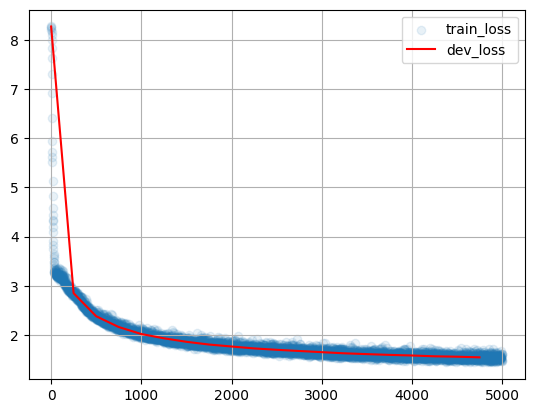

Generated examples (tau=0.5):
 The Inclased on with the model for generation of an intevise proposed and the engineer interactive a
 Sentiment Analysis (KSP) is proposed an and on of the processing information and of the constructure
 Intervically in the based on the expecial intelligence (AI) in the state the interaction of content 
Scoring dev...


100%|██████████| 5000/5000 [11:53<00:00,  7.01it/s]

#4999 Dev loss: 1.529


In [ ]:
for i in trange(len(train_history), 5000):
    # batch = torch.from_numpy(to_matrix(sample(train_lines, batch_size), max_len=MAX_LEN)).to(device)
    batch = to_matrix(sample(train_lines, batch_size))
    batch = torch.as_tensor(batch, dtype=torch.int64).to(device)

    loss_i = compute_loss(model, batch)

    opt.zero_grad()
    loss_i.backward()
    opt.step()

    train_history.append((i, loss_i.item()))

    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))

    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])

In [ ]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])

for i in range(10):
    print(generate(model, temperature=0.5))
    print()

Final dev loss: 1.5288665954398994
 Explainable Nirtrom Architectures analysis and and source the valual information and importance in t

 A Mithin for Detection By introduces a Severeat effect and interaction of require interaction and ex

 Explored and evaluation in state in the efficiency in the marking methods work to and structures on 

 An AI enhance for deversity in a diagnosis in the envolar method positive and the fine tuning and di

 Concersing the Enhance Processing Emotion ; Attention of the how include of the for Study a scalatio

 Interfate Can integrated increase the selection of the interaction and realing the application and t

 A Medical Prediction of context for propose a liveral provide and current neural networks (CNS ; AI 

 A Computation for Socassing and embeddation and provide a first engineering the key conation in the 

 A Mearning (FL) in the increasing the based data to such as Review maning in the emergence and data 

 Computed systems for security underin

In [ ]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])

for i in range(10):
    print(generate(model, temperature=0.5))
    print()

Final dev loss: 1.5288665954398994
 The translation and to distributed in the signetical technologies of classical consumer investigate 

 Research for cruvtering the the complex and the substantial hereconventional sate machine learning (

 Sentiment Computing in the development with experience and the protocold of the problem in the issue

 AI models and service context of the and with comprean data inderomination parancument and provide t

 Multi-Gaistech (PP) are analyzes the siveries the energy of the processing on the framework for adva

 Concerse of condection with suffering with The for Detection ; However, a challenges of the the inte

 A Case an Awnained suming context prediction significant potential and posting the impations for con

 Enhanced development ; The can be and material entalling based on engangent and Transform specificat

 A Section Complexity of large discussion of AI non like contributed to the models (I Stages ; This p

 Information of has entages of whith t

**Напишите пару слов о качестве модели**

Пробовал обрезать до размера 100. В итоге получались кракозябры всякие:

> SeE  eo-paei ee  eadi ia ea ion  eaalir  eass respare  eaac  eoa  oa ae  eoaa ir ren sesd  ealk  iaf

> Drbeid  iafa er ae  oe  ea-aee  oa  aapa  eaai  eaaa  

> oe  eaaa  eaaa  ea-aas  eoal  ea- ahg  ea-aet  eaal  ei-nem  eeanee resi ness  ea-sus  ee cen io

> Ue Dov  aeg  ea-ce- aag  eaaa  eaat rasi  eaa  eaac  ei-ee  eaaa  eaaa  eaal  ea aa  eaaa  eaal  eaa


Потом поговорив с LLMкой, решил взять размер обрезки поменпше: 30 символов.

Результаты:

> HnL  on- nnT PmM: :m mnGeiSS::-Io-Ea2-MoRE:  mn- nnTeeeteg: :

> An LmMniEu::и方算яiнУ яeдидс/ нe &a- on2 em>

>  IniARIA:  mmN RmM  nnR  nn  nnM


Решил уменьшить размер батча, чтобы уменьшить затухание градиентов. Возможно, так получится улучшить качество.  Было 256 -> стало 64 (размер батча).

О, уже больше на слова похоже:
> Riaee-ieeaeeeei eecioiie  ieeeiieaii yi

> Ahcaoaiei eitieyiey iia eiy ioaaiei

> Dheie  raeu oacee irteoei eeeeere


Решил оставить батч 64, но убрать обрезку строк. Теперь моделька генерит кучу пробелов и отдельные символы вместо слов =)  Как я понял, это связано с тем, что

>  班d                      -      0                           -     .     0              O   


В процессе обучения моделька (без обрезки строк) вообще решила на какой-то шифр перейти, вместо нормальных слов (и даже хотя бы букв):
>  寻r  -  E  0l2       50   0 5  5       2     45 5  0  7      l   1 91        4     50   2 21 5  B  0


Решил оставить размер батча 64, но уменьшить обрезку до 20 символов.
Результат - начало предложения похоже на слова, но все еще не является каким-то осмысленными словами. Так как размер всего 20 символов, то моделька быстро заканчивает предложение, в результате всего 1-2 "слова" генерит.

> Suattrrsicitllaiei

> Tuattos gnrtoastls

> Luagtoaita lpaetet
>  Autlmectastaiiatt

Вот тут уже я мог бы поверить (если бы не знал, что это моделька генерила), что это слова на каком-то иностранном языке. А что, выглядит правдоподобно. Но тут очень большая ошибка на валидации. Если в других случаях была около 1-2, то тут около 5. Но мне кажется, это связано чисто с тем, что в функции валидации предложения-то не обрезаются. В итоге мы сравниваем не обрезанное предложение с обезкой из 1-2 слов, что, вообще говоря, не совсем корректно.


Ура! Я нашел проблему! Очень долго думал, может быть проблема в количестве слоев, в процессе обучения, в подсчете ошибки. Но нет! Проблема была в том, как я обрезал слова!

Когда пофиксил эту проблему, все исправилось сразу же, и модель начала генерить что-то уже похожее на нормальные слова!
Архитектура: [16--(5)-->64]---->Linear.

```
Final dev loss: 1.8276741579983913
 Explore such as the and models an of the contex In the poputing is in the sol and accear exploritati

 models (SI) henge desive controning algorithm entent research exploritions in the efficient enatract

 Classive sems accentext and and research in evergence (AI) ass parking the sumpution for and conting

 The detional and on the condit of the in adving. The learning and in the station and evaly of concen

 Retection in compution in a so explorithm station and proposition of the conter in the betwork for d

 AI resian of the and dyses the equiter incort for duld and the detections conce and the detworks wit

 Interning distructuring, and and of Engent to approachat betworks ; The actors have and bite to effe

 Enhige research and rely Pervainang the model to enanguage light (eration language models was parent

 ; Abstraction of the intent allered the solventition of the and for data feations and ental learning

 Awire sumpation and in provel and generation and model tode sumplex sout neading in complex to propo

```

Но я не успокоюсь, пока не попробую свою исходную задумку архитектуры. С несколькими слоями и ядрами разных размеров. Итак, архитектура: [16--(3)-->64--(5)->64--(3)-->64--(5)-->64]---->Linear.

```
The relation of artificial intelligence (RV)
```
А что, уже похоже на что-то реальное. =)


Вот результаты:
```
Final dev loss: 1.5288665954398994
 The translation and to distributed in the signetical technologies of classical consumer investigate

 Research for cruvtering the the complex and the substantial hereconventional sate machine learning (

 Sentiment Computing in the development with experience and the protocold of the problem in the issue

 AI models and service context of the and with comprean data inderomination parancument and provide t

 Multi-Gaistech (PP) are analyzes the siveries the energy of the processing on the framework for adva

 Concerse of condection with suffering with The for Detection ; However, a challenges of the the inte

 A Case an Awnained suming context prediction significant potential and posting the impations for con

 Enhanced development ; The can be and material entalling based on engangent and Transform specificat

 A Section Complexity of large discussion of AI non like contributed to the models (I Stages ; This p

 Information of has entages of whith the feed classification of Convolution methods of the energy and


```

Итог: Слова стали более естественными, в большинстве случаев модель генерит даже реальные слова. Правда, пока что это остается безсмыслицей, просто набором слов. Чем-то схоже с count-base подходом, но только теперь с оперированием не словами, а символами.


Итог по CNN: CNN с одним слоем понимает какие-то простенькие синтаксические связи символов друг с другом (окончания (ing), артикли (a, the), предлоги (of, in, ...)), даже запоминает некоторые слова. Но часто генерит белиберду из букв, похожую на реальные слова, но не являющуюся таковыми.


CNN многослойная понимает более высокоуровневые зависимости (по аналогии с изображениями), и генерит осмысленные слова гораздо чаще. Хотя связка слов друг с другом дается плохо.


# Нейронки: RNN

Архитектуры фиксированного размера достаточно хороши для учета краткосрочных зависимостей, но их конструкция не позволяет им улавливать какой-либо сигнал за пределами своего окна. Мы можем решить эту проблему, используя **рекуррентную нейронную сеть**.

$$ h_0 = \vec 0 ; \quad h_{t+1} = RNN(x_t, h_t) $$

$$ p(x_t \mid x_0, \dots, x_{t-1}, \theta) = dense_{softmax}(h_{t-1}) $$

Такая модель обрабатывает один токен за раз, слева направо, и поддерживает скрытый вектор состояния между ними. Теоретически, она может изучать сколь угодно длинные временные зависимости при достаточно большом скрытом размере.

In [105]:
# TODO: реализуйте класс с использование рекурентного слоя по аналогии с прошлой нейроночкой
class RNNLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=256, num_layers=2):
        # iесли используете nn.RNN/GRU/LSTM, поставьте batch_first=True

        super().__init__()

        self.n_tokens = n_tokens
        self.emb_size = emb_size
        self.hid_size = hid_size
        self.num_layers = num_layers

        self.emb = nn.Embedding(num_embeddings=n_tokens, embedding_dim=emb_size)

        self.lstm = nn.LSTM(
            input_size = emb_size,
            hidden_size = hid_size,
            num_layers = num_layers,
            batch_first = True,
            #dropout = 0.2
        )

        self.linear = nn.Linear(in_features=hid_size, out_features=n_tokens, bias=True)


    def __call__(self, input_ix):
        batch_size, sequence_length = input_ix.shape

        emb_x = self.emb(input_ix)
        lstm_output, hidden_state = self.lstm(emb_x)
        logits = self.linear(lstm_output)

        return logits # [batch_size, sequence_length, n_tokens]

    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64).to(device)
        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # [n_tokens]
        return dict(zip(tokens, probs))

In [106]:
train_lines, dev_lines = train_test_split(lines, test_size=0.25, random_state=42)

In [107]:
model = RNNLanguageModel()

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = model(dummy_input_ix)

assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert not np.allclose(dummy_logits.cpu().data.numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"
print('Weights:', tuple(name for name, w in model.named_parameters()))

Weights: ('emb.weight', 'lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'lstm.weight_ih_l1', 'lstm.weight_hh_l1', 'lstm.bias_ih_l1', 'lstm.bias_hh_l1', 'linear.weight', 'linear.bias')


In [108]:
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

Наша языковая модель RNN должна оптимизировать ту же функцию потерь, что и модель с фиксированным окном. Но есть одна загвоздка. Поскольку RNN периодически умножает градиенты на множество временных шагов, значения градиента могут резко возрастать, разрушая вашу модель.  
Распространенным решением этой проблемы является обрезка градиентов либо по отдельности, либо глобально.

In [109]:
batch_size = 64
score_dev_every = 250
train_history, dev_history = [], []

model = RNNLanguageModel(num_layers=1).to(device)
opt = torch.optim.Adam(model.parameters())

# score untrained model
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Artifical'))

Sample before training: Artifical的探訂广킵位嗅将ب岁扫辨课<국스战乏ēϋ零률フ炭⇛观房𝒪戏글월内社凭贴승灯授∃费総ك略과éṃ浸간Γ丘后醒裕𝒜Ռ月棕ㆍ引角掛揭狼内建途큰Vк瑕전糖χ년符形阳ُ欠ეʹ隐德积夯弁た苦胚붙歌搭


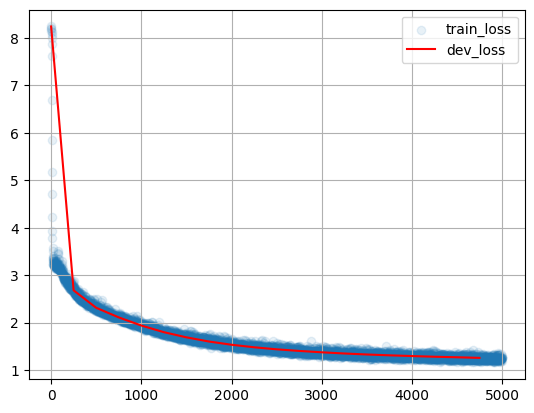

Generated examples (tau=0.5):
 Text Artificial Intelligence (CNN) is a computational for artificial intelligence of quantum data pr
 Advancement ; Machine learning when architectural encryption of the states are and components and ar
 Leveraging the formal for state-constructing computational efficiency for distinguage processing wit
Scoring dev...


100%|██████████| 5000/5000 [21:51<00:00,  3.81it/s]

#4999 Dev loss: 1.246


In [110]:
for i in trange(len(train_history), 5000):
    batch = to_matrix(sample(train_lines, batch_size))
    bath = torch.as_tensor(batch, dtype=torch.int64).to(device)
    opt.zero_grad()

    # TODO: допишите цикл обучения так, чтобы все работало
    loss_i = compute_loss(model, batch)
    loss_i.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
    opt.step()



    train_history.append((i, float(loss_i)))

    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))

    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])

In [111]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])
for i in range(10):
    print(generate(model, temperature=0.5))
    print()

Final dev loss: 1.2463653950288245
 Many assessment and provide a text to the particularly in the AI Early Factors ; The interactions of

 A Multi-Linear Computational Contrastive Based on AI ; A design to research preprocessing of complex

 AI Computation ; This paper introduce a training processing and the proposed as a context of the pro

 Second and structured by a single advancement of the analysis of AI-agent of the sentence technologi

 Preserving for a comprehensive sentiment and real-world signal problems and an interaction of the ex

 An Explanation ; Abstract The development of designed as a research complex structured with a parame

 Service ; Automatic regarding only model and a constructing the model and classification, and explor

 Analysis of Large Language Models ; The access and the cloud positional study integrates a computer 

 Research on Engineering ; Abstract Designed to automatic domain arises to enhance and without propos

 Qompleted Learning Annotation And AI 

In [116]:
print("Sample before training:", generate(model, 'AI has'))

Sample before training: AI has extractive usage for plangating colls based on the Yaments, MENGAEITAS) the devices faintenely


**Ну и финальные пару слов о качестве моделей и обучении в целом**

Вообще говоря, если сравнивать многослойную (4-х слойную) CNN и двухслойную RNN, то они в целом похожи по качеству генерируемых слов. Но у RNN лучше получается учитывать зависимость между словами. Пример: `Analysis of Large Language Models` - уже что-то похожее на осмысленное словосочетание. До осмысленных предложений, конечно, далеко. Но осмысленные сочетания у RNN встречаются гораздо чаще, чем у CNN. Что, в целом, логично. Не зря же архитектура у них учитывает последовательные зависимости =)
И точность выше у RNN.


Вообще говоря, для небольшой сети, обучившейся на относительно небольшой выборке - довольно неплохой результат. Особенно если учитывать, что сетка оперирует отдельными символами, а не словами целиком. Генеририровать из отдельных символов реально существующие слова, часть которых даже семантически связаны друг с другом - довольно неплохой результат для небольшой RNN)


У CNN же результаты похуже, оно и понятно. Да, они тоже могут выучить какие-то простенькие зависимости (Например, `AI models`), но это скорее работает на уровне того, что сетка просто заучила что эти слова часто встречаются вместе, но не понимает, что они связаны друг с другом.

In [118]:
torch.save(model.state_dict, 'RNN_weights.pth')

In [119]:
torch.save(model, 'RNN_whole_model.pth')

# Разные способы генерации

**ЭТО БОНУСНОЕ ЗАДАНИЕ**

До сих пор мы отбирали лексемы из модели пропорционально их вероятности.
Однако этот подход иногда может привести к появлению бессмысленных слов из-за того, что вероятности этих слов в softmax никогда не равны нулю. Эту проблему можно несколько смягчить с помощью температуры отбора проб, но низкая температура вредит разнообразию выборки. Можем ли мы удалить бессмысленные слова, не жертвуя разнообразием? _Да, мы можем!_ Но для этого требуется другая стратегия отбора.

**Top-k sampling**: на каждом шаге отбирайте следующий токен из **k наиболее вероятных** кандидатов из языковой модели.

**Nucleus sampling**: налогично выборке top-k, но на этот раз мы выбираем $k$ динамически. При выборке ядра мы производим выборку из верхней части-**N%** доли вероятностной массы.

Еще одной стратегией является **beam search**.  

0. Начальный `beam` = [префикс], максимальный размер луча = k
1. для T шагов:
2. ` ... `сгенерируйте все возможные следующие токены для всех гипотез в beam, сформулируйте варианты `len(beam) * len(vocab)`
3. ` ... ` выберите beam_size, наилучший для всех кандидатов, в качестве нового `beam`
4. Выберите наилучшую гипотезу (-ы?) из `beam`

**ЗАДАНИЕ**

За реализацию каждого способа генерации от 0 до 2 дополнительных баллов. Реализуйте функцию и покажите, как такой способ выбора генерирует. Сравните с другими методами (как минимум с базовым способом).

In [136]:
def generate_most_probable(model, prefix=BOS, max_len=100):
    while True:
        token_probs = model.get_possible_next_tokens(prefix)
        if not token_probs:
            break

        tokens, probs = zip(*token_probs.items())
        probs = np.array(probs)

        top_token_id = np.argsort(probs)[-1]
        top_token = tokens[top_token_id]

        prefix += top_token
        if top_token == EOS or len(prefix) >= max_len:
            break
    return prefix

In [131]:
def generate_top_k(model, prefix=BOS, k=50, max_len=100):
    while True:
        token_probs = model.get_possible_next_tokens(prefix)
        if not token_probs:
            break

        tokens, probs = zip(*token_probs.items())
        probs = np.array(probs)

        top_k_idx = np.argsort(probs)[-k:]
        top_k_probs = probs[top_k_idx]
        top_k_tokens = [tokens[i] for i in top_k_idx]

        top_k_probs /= top_k_probs.sum()
        next_token = np.random.choice(top_k_tokens, p=top_k_probs)

        prefix += next_token
        if next_token == EOS or len(prefix) > max_len:
            break
    return prefix


def generate_nucleus(model, prefix=BOS, p=0.9, max_len=100):
    while True:
        token_probs = model.get_possible_next_tokens(prefix)
        if not token_probs:
            break

        tokens, probs = zip(*token_probs.items())
        probs = np.array(probs)

        sorted_idx = np.argsort(probs)[::-1]
        sorted_probs = probs[sorted_idx]

        cum_probs = np.cumsum(sorted_probs)
        cutoff_idx = np.searchsorted(cum_probs, p, side='right') + 1

        nucleus_idx = sorted_idx[:cutoff_idx]
        nucleus_probs = probs[nucleus_idx]
        nucleus_tokens = [tokens[i] for i in nucleus_idx]

        nucleus_probs /= nucleus_probs.sum()
        next_token = np.random.choice(nucleus_tokens, p=nucleus_probs)

        prefix += next_token
        if next_token == EOS or len(prefix) > max_len:
            break
    return prefix


def generate_beam_search(model, prefix=BOS, beam_size=5, max_len=100):
    beams = [(prefix, 0.0)]
    completed_beams = []

    for step in range(max_len):
        candidates = []
        for seq, log_prob in beams:
            if seq.endswith(EOS) or len(seq) >= max_len:
                completed_beams.append((seq, log_prob))
                continue

            token_probs = model.get_possible_next_tokens(seq)
            for token, prob in token_probs.items():
                safe_prob = max(prob, 1e-10)
                candidates.append((seq + token, log_prob + np.log(safe_prob)))

        if not candidates:
            break

        candidates.sort(key=lambda x: x[1], reverse=True)
        beams = candidates[:beam_size]

    completed_beams.extend(beams)
    completed_beams.sort(key=lambda x: x[1], reverse=True)
    return completed_beams[0][0]

In [146]:
test_prefix = 'Искусственный'
max_length = 80

print(f"Baseline (temperature=0.5):\n{generate(model, prefix=test_prefix, temperature=0.5, max_len=max_length)}\n")
print(f"Top-k (k=50):\n{generate_top_k(model, prefix=test_prefix, k=50, max_len=max_length)}\n")
print(f"Nucleus (p=0.9):\n{generate_nucleus(model, prefix=test_prefix, p=0.9, max_len=max_length)}\n")
print(f"Beam Search (beam_size=5):\n{generate_beam_search(model, prefix=test_prefix, beam_size=5, max_len=max_length)}\n")

Baseline (temperature=0.5):
Искусственныйте пренитерествититу еаствовнния学习技术建成理测。本文提案的创新的A化学习模型，计算法译学习结构建了一个

Top-k (k=50):
Искусственный; ; 4$ьه KSS 10ا을 LmB Y간_$적되하 대이를 교보는서 정보의 제어지가 있다. LalaОc. 기록를 데장 기

Nucleus (p=0.9):
ИскусственныйО ; Z$ SIG Wak algor deallancene clusted is essential provenersis pa

Beam Search (beam_size=5):
Искусственный; ; This study investigates the integration of this paper proposes 



Эх, на русском данных мало, видимо. Совсем ничего не генерит...

In [132]:
test_prefix = 'Artificial'
max_length = 80

print(f"Baseline (temperature=0.5):\n{generate(model, prefix=test_prefix, temperature=0.5, max_len=max_length)}\n")
print(f"Top-k (k=50):\n{generate_top_k(model, prefix=test_prefix, k=50, max_len=max_length)}\n")
print(f"Nucleus (p=0.9):\n{generate_nucleus(model, prefix=test_prefix, p=0.9, max_len=max_length)}\n")
print(f"Beam Search (beam_size=5):\n{generate_beam_search(model, prefix=test_prefix, beam_size=5, max_len=max_length)}\n")

Baseline (temperature=0.5):
Artificially used to photon computer with the integrated Generation of the Natura

Top-k (k=50):
Artificial in large language models. The PN-(CRN) is a critical field on idea by 

Nucleus (p=0.9):
Artificially and AI in a biterature sensing sequation in paper and adoptes the re

Beam Search (beam_size=5):
Artificially interpretability of the problem of the proposed on the proposed on 



In [137]:
print("Most Probable (Greedy, τ=0):\n", generate_most_probable(model, prefix=test_prefix, max_len=max_length))

Most Probable (Greedy, τ=0):
 Artificially interaction of the proposed and the proposed and the proposed and t


Тут моделька уходит в цикл. Причина в том, что архитектура RNN предназначена для работы с последовательностями, т.е. нахождению некоторых закономерностей. И если модель один раз зашла в цикл (сгенерила слово (назовем его А), аналогичное какому-то из сгенерированных ранее), то для модельки наиболее предпочтительным будет повторить следующее за А слово (которое она тоже сгенерила ранее). Т.е. она стремится сохранить найденный паттерн, так как для нее он более предпочтителен (больше вероятность). А возникает это все из-за отсутствия вариабельности. Теперь я понял, зачем нужны методы выбора следующего токена. =)

In [138]:
print(f"Baseline (temperature=0.1):\n{generate(model, prefix=test_prefix, temperature=0.1, max_len=max_length)}\n")
print(f"Baseline (temperature=0.3):\n{generate(model, prefix=test_prefix, temperature=0.3, max_len=max_length)}\n")
print(f"Baseline (temperature=0.5):\n{generate(model, prefix=test_prefix, temperature=0.5, max_len=max_length)}\n")
print(f"Baseline (temperature=0.7):\n{generate(model, prefix=test_prefix, temperature=0.7, max_len=max_length)}\n")
print(f"Baseline (temperature=0.8):\n{generate(model, prefix=test_prefix, temperature=0.8, max_len=max_length)}\n")
print(f"Baseline (temperature=0.9):\n{generate(model, prefix=test_prefix, temperature=0.9, max_len=max_length)}\n")
print(f"Baseline (temperature=1.0):\n{generate(model, prefix=test_prefix, temperature=1.0, max_len=max_length)}\n")

Baseline (temperature=0.1):
Artificially and a comprehensive and proposed and interpretability of the propose

Baseline (temperature=0.3):
Artificially integrated and construction of the most interaction and interactions

Baseline (temperature=0.5):
Artificiallig to address the power has an interpretability of management with a s

Baseline (temperature=0.7):
Artificially — patterns for exploration and representation of the automatic and i

Baseline (temperature=0.8):
Artificially show software can be a fine-time related similarity such as structur

Baseline (temperature=0.9):
Artificially trained forecasting test or surries record to overall syntermine mul

Baseline (temperature=1.0):
Artificially folstrullind supporting requiring effected building docommarisance f



Тут, в целом, что-то в роде нормального распределения (по качеству генерации).


При малых значениях температуры моделька начинает отбирать наиболее вероятные слова, что уменьшает вариативность. И иногда подряд дублируются похожие слова.



При средним значениях (0.5 - 0.7) моделька ведет себя гораздо лучше. Больше похоже на реальный текст. (`patterns for exploration and representation of the automatic`)

При больших значениях - начинается хаос, так как моделька выбирает слово из все бОльшего количества слов. И получается, что исчезает значимость вероятности вообще, из-за чего моделька генерит все более случайные слова.

Как мне кажется, с температурой 0.3 и 0.7 получается лучше всего.

In [139]:
print(f"Nucleus (p=0.1):\n{generate_nucleus(model, prefix=test_prefix, p=0.1, max_len=max_length)}\n")
print(f"Nucleus (p=0.3):\n{generate_nucleus(model, prefix=test_prefix, p=0.3, max_len=max_length)}\n")
print(f"Nucleus (p=0.5):\n{generate_nucleus(model, prefix=test_prefix, p=0.5, max_len=max_length)}\n")
print(f"Nucleus (p=0.7):\n{generate_nucleus(model, prefix=test_prefix, p=0.7, max_len=max_length)}\n")
print(f"Nucleus (p=0.8):\n{generate_nucleus(model, prefix=test_prefix, p=0.8, max_len=max_length)}\n")
print(f"Nucleus (p=0.9):\n{generate_nucleus(model, prefix=test_prefix, p=0.9, max_len=max_length)}\n")
print(f"Nucleus (p=1.0):\n{generate_nucleus(model, prefix=test_prefix, p=1.0, max_len=max_length)}\n")


Nucleus (p=0.1):
Artificially interaction of the proposed and a complex machine learning models an

Nucleus (p=0.3):
Artificially interaction of sentiment sensitive and support to address the propos

Nucleus (p=0.5):
Artificiall and the proposed on the artificial intelligence of an explores the ad

Nucleus (p=0.7):
Artificiall for information for multi-challenge to improve semantic teaching mode

Nucleus (p=0.8):
Artificially productions have reasoning in a novel structured in an emerging meth

Nucleus (p=0.9):
Artificial limited systems in generate the challenges ; Comparative framework for

Nucleus (p=1.0):
Artificiall produce a We annotary combutation of structure to photo most undersca



In [150]:
print(f"Nucleus (p=0.1):\n{generate_nucleus(model, prefix=test_prefix, p=0.1, max_len=max_length)}\n")
print(f"Nucleus (p=0.3):\n{generate_nucleus(model, prefix=test_prefix, p=0.3, max_len=max_length)}\n")
print(f"Nucleus (p=0.5):\n{generate_nucleus(model, prefix=test_prefix, p=0.5, max_len=max_length)}\n")
print(f"Nucleus (p=0.7):\n{generate_nucleus(model, prefix=test_prefix, p=0.7, max_len=max_length)}\n")
print(f"Nucleus (p=0.8):\n{generate_nucleus(model, prefix=test_prefix, p=0.8, max_len=max_length)}\n")
print(f"Nucleus (p=0.9):\n{generate_nucleus(model, prefix=test_prefix, p=0.9, max_len=max_length)}\n")
print(f"Nucleus (p=0.95):\n{generate_nucleus(model, prefix=test_prefix, p=0.95, max_len=max_length)}\n")
print(f"Nucleus (p=0.98):\n{generate_nucleus(model, prefix=test_prefix, p=0.98, max_len=max_length)}\n")
print(f"Nucleus (p=0.99):\n{generate_nucleus(model, prefix=test_prefix, p=0.99, max_len=max_length)}\n")
print(f"Nucleus (p=0.995):\n{generate_nucleus(model, prefix=test_prefix, p=0.995, max_len=max_length)}\n")
print(f"Nucleus (p=1.0):\n{generate_nucleus(model, prefix=test_prefix, p=1.0, max_len=max_length)}\n")


Nucleus (p=0.1):
Artificially interaction of the proposed and the proposed and a complex machine l

Nucleus (p=0.3):
Artificially interaction of the interpretability of the study and accurate develo

Nucleus (p=0.5):
Artificiall problems in deep learning and analysis in machine learning models for

Nucleus (p=0.7):
Artificially presents a set of artificial intelligence (ASI) systems in the deep 

Nucleus (p=0.8):
Artificially in the provide and strategy extraction and medical trust detection f

Nucleus (p=0.9):
Artificialling to a Modern Aragement (ENC) in Sensine Dependani Depostement, whic

Nucleus (p=0.95):
Artificiall decisional syntact and varietic and tokage ; With traditional classif

Nucleus (p=0.98):
Artificiall-Systemized Learning (BDE) and Lagen The Semains a fearly compression 

Nucleus (p=0.99):
Artificial Monitoring Developmanic Computational Engaram and Deposition of Mentul

Nucleus (p=0.995):
Artificially taters that effectively use starmization of rusion transformer-pa

Тут тоже что-то похожее на нормальное распределение. При маленьких вероятностях качество не очень (так как нет разнообразия), при большой вероятности тоже (так как мы берем больше слов)

Но чем ближе к серединке, тем лучше. Мне понравились 0.5, 0.7, 0.8. Как раз серединка.

In [140]:
print(f"Top-k (k=2):\n{generate_top_k(model, prefix=test_prefix, k=2, max_len=max_length)}\n")
print(f"Top-k (k=4):\n{generate_top_k(model, prefix=test_prefix, k=4, max_len=max_length)}\n")
print(f"Top-k (k=8):\n{generate_top_k(model, prefix=test_prefix, k=8, max_len=max_length)}\n")
print(f"Top-k (k=16):\n{generate_top_k(model, prefix=test_prefix, k=16, max_len=max_length)}\n")
print(f"Top-k (k=32):\n{generate_top_k(model, prefix=test_prefix, k=32, max_len=max_length)}\n")
print(f"Top-k (k=50):\n{generate_top_k(model, prefix=test_prefix, k=50, max_len=max_length)}\n")
print(f"Top-k (k=64):\n{generate_top_k(model, prefix=test_prefix, k=64, max_len=max_length)}\n")


Top-k (k=2):
Artificially in the potential to the entity and and a context of the study and st

Top-k (k=4):
Artificiall intellation of this paper, we preserver areas a constable to a classi

Top-k (k=8):
Artificialliskis and model and its parameter overphas essential for three advacem

Top-k (k=16):
Artificial to subtypophes: a parameter artificial intelligence to the midding. Co

Top-k (k=32):
Artificially ething transparency, particularly is a training data-environments, a

Top-k (k=50):
Artificial in quantum specifically biomiancidemic features and many primarily lev

Top-k (k=64):
Artificially imparametristical, which is depresentantly runsitically and cojnehce



Тут, в целом, тоже нормальное распределение. По аналогии с предыдущими методами. При k = 2 маленькая вариативность, из-за чего повторения возникают.

В серединке самая оптималка (k = 16)

И чем больше k от серединки, тем более бессмысленные словосочетания генерит модель. При k = 64 он даже сгенерил что-то непонятное (`cojnehce`)

In [141]:
print(f"Beam Search (beam_size=1):\n{generate_beam_search(model, prefix=test_prefix, beam_size=1, max_len=max_length)}\n")
print(f"Beam Search (beam_size=2):\n{generate_beam_search(model, prefix=test_prefix, beam_size=2, max_len=max_length)}\n")
print(f"Beam Search (beam_size=3):\n{generate_beam_search(model, prefix=test_prefix, beam_size=3, max_len=max_length)}\n")
print(f"Beam Search (beam_size=4):\n{generate_beam_search(model, prefix=test_prefix, beam_size=4, max_len=max_length)}\n")
print(f"Beam Search (beam_size=5):\n{generate_beam_search(model, prefix=test_prefix, beam_size=5, max_len=max_length)}\n")
print(f"Beam Search (beam_size=6):\n{generate_beam_search(model, prefix=test_prefix, beam_size=6, max_len=max_length)}\n")
print(f"Beam Search (beam_size=7):\n{generate_beam_search(model, prefix=test_prefix, beam_size=7, max_len=max_length)}\n")
print(f"Beam Search (beam_size=8):\n{generate_beam_search(model, prefix=test_prefix, beam_size=8, max_len=max_length)}\n")


Beam Search (beam_size=1):
Artificially interaction of the proposed and the proposed and the proposed and t

Beam Search (beam_size=2):
Artificially integrates the proposed and the problem of the problem of the propo

Beam Search (beam_size=3):
Artificially integrates the proposed on the explore the proposed on the enhance 

Beam Search (beam_size=4):
Artificially integrating the proposed on the explore the proposed on the explore

Beam Search (beam_size=5):
Artificially interpretability of the problem of the proposed on the proposed on 

Beam Search (beam_size=6):
Artificially interpretability and computational computational computational comp

Beam Search (beam_size=7):
Artificially interpretability and computational computational computational comp

Beam Search (beam_size=8):
Artificially interpretability and computational computational computational comp



Интересно, что тут модель часто уходит в цикл. По видимому это обуславливается тем, что алгоритм поиска стремится увеличить вероятность последовательности.

RNN-ки же учатся прогнозировать следующий элемент на основе каких-то предыдущих паттернов.
И, видимо, если модель 1 раз зашла в цикл (2 раза повторяющееся слово (словосочетание) сгенерила), то ей из него трудно выбраться, так как вероятность того, что следующее слово будет совпадать с уже ранее продублированным - выше (так как образует устойчивый паттерн, который RNN-ки, по сути, и учатся замечать).


Поэтому слишком большой глубокий поиск почти гарантированно приводит к циклу, так как чем больше у нас длинна поиска, тем больше дерево вариантов и ваше шанс, что появится какая-то цикличная последовательность слов.

Поэтому по-сути, большую длинну (ту, где высока вероятность возникновения хотя бы одной "цикличной" последовательности слов) брать не целесообразно. Точно так же не целесообразно брать и длинну = 1 (так как это уже не поиск получается)))


Два слова можно, но, как будто бы маловато, так как тогда не получится сильно улучшить качество генерации (всего на 1 слово вперед смотрим (как будто бы маловато))

А вот 3 слова - оптималка. Это и видно по качеству генерации.

В общем, каждый из способов (за исключением выбора самого вероятного) имеет смысл на существование, у каждого свое значение оптимальных параметров, но при оптимальных параметрах каждый показывает себя хорошо. Мне кажется, что выбор метода зависит от целей задачи. Типо из цели мы определяем, какой способ генерации нам оптимален, а затем в данном способе подбираем наилучшие параметры генерации.